In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['ps.fonttype'] = 42
# ps font as helvetica
rcParams['ps.useafm'] = True
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [46]:
from catrace.run.run_distance import run_distance, RunDistanceParams, PlotDistanceParams, PlotMeanDeltaMatParams
from catrace.visualize import PlotBoxplotParams, PlotBoxplotMultiOdorCondParams, PlotPerCondMatParams

Plotting average trace...
Extracted_Data_mock1_Fish1 None
Computing distance matrices...
F:\FMI_tachyon_hubo\Dp_manifold\BNP_dataset\data\Claire\spike_prob\dorsal\per_odor_aligned\index_formatted_firing_rate\mahal_seed203_window47to70_shuffled_seed121
Plotting per condition...
{'ncol': 2, 'row_height': 1.35, 'col_width': 1.35, 'title_fontsize': 7, 'colorbar_fontsize': 6, 'ylabel_fontsize': 7, 'ylabels': None, 'ylabel_colors': None, 'cmap': 'turbo', 'clim': [7.618662656572846, 319.53582136515286], 'color_norm': None, 'cbar_interval': None, 'manifold_level': 'odor'}
clim: (7.618662656572846, 319.53582136515286)
ylabel_ vfontsize: 7
ylabel_ vfontsize: 7
Plotting delta matrix...
clim: (-135.9960208056082, 135.9960208056082)
ylabel_ vfontsize: 7
Plotting vs statistics...
Plotting per fish...


C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(


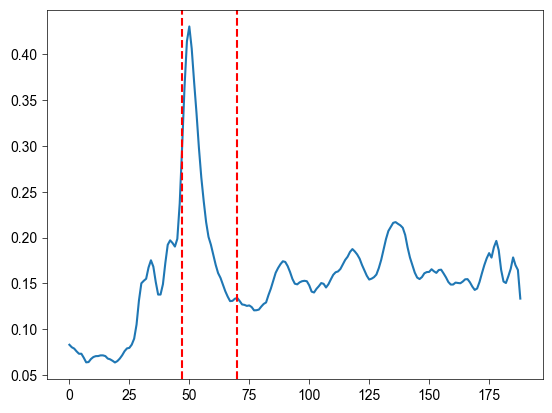

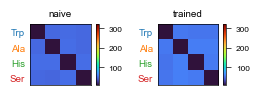

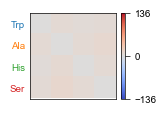

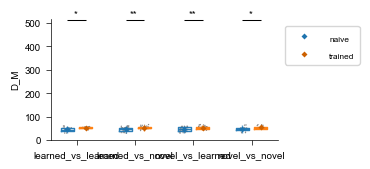

In [47]:
ylabels = None
ylabel_colors = None
plot_params = PlotDistanceParams(
    per_cond = PlotPerCondMatParams(
        row_height=1.35,
        col_width=1.35,
        title_fontsize=7,
        ylabel_fontsize=7,
        ylabel_colors = ylabel_colors,
        ylabels = ylabels,
        clim=(7.618662656572846, 319.53582136515286)),
    mean_delta = PlotMeanDeltaMatParams(
        figsize=(1.77, 1.77),
        colorbar_fontsize = 7,
        ylabel_fontsize = 7,
        ylabels = ylabels,
        ylabel_colors = ylabel_colors,
        clim=(-135.9960208056082, 135.9960208056082),
    ),
    vs_measure = PlotBoxplotMultiOdorCondParams(
        figsize=(3.8, 1.8),
        label_fontsize=7,
        show_ns=True,
        box_linewidth=1,
        strip_size=1,
        mean_marker_size=1,
        pvalue_marker_xoffset=0.05,
        pvalue_bar_linewidth=0.75,
        ylim=(0, 518.1999733753291),
    )
    )

config_file = '../dataset_configs/adult_dataset_t7.json'
from catrace.dataset import load_dataset_config
dsconfig = load_dataset_config(config_file)

vsdict = {'learned_vs_learned': (dsconfig.odors_learned, dsconfig.odors_learned),
          'learned_vs_novel': (dsconfig.odors_learned, dsconfig.odors_novel),
          'novel_vs_learned': (dsconfig.odors_novel, dsconfig.odors_learned),
          'novel_vs_novel': (dsconfig.odors_novel, dsconfig.odors_novel)
}
seed = 203
shuffle_master_seed = 121
params = RunDistanceParams(
    config_file = config_file,
    assembly_name = '',
    time_window = [47, 70],#[40, 78],
    sample_size = 70,
    metric = 'mahal',
    seed=seed,
    do_normalize_simdf = False,
    do_reorder_cs = False,
    overwrite_computation = False,
    vsnames = ['learned_vs_learned', 'learned_vs_novel', 'novel_vs_learned', 'novel_vs_novel'],
    vs_same_ylim=None,#[90, 370],
    reg=1e-5,
    do_plot_per_fish = False,
    vsdict=vsdict,
    plot_params = plot_params,
    parallelism = 20,
    num_repeats = 50,
    do_shuffle_manifold_pair_labels = True,
    shuffle_master_seed = shuffle_master_seed,
    manifold_level = 'odor')

if params.assembly_name == '':
    assembly_label = 'all_neurons'
else:
    assembly_label = params.assembly_name
params.summary_name = f'distance_summary_{params.metric}_{assembly_label}_window{params.time_window[0]}to{params.time_window[1]}_norm{params.do_normalize_simdf}'

output_figs, test_results, avg_simdf  = run_distance(params, return_data=True)

# Save result data to CSV
import os
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure06')
os.makedirs(save_dir, exist_ok=True)
avg_simdf.to_csv(os.path.join(save_dir, f'extended_figure06d_adult_shuffled_mahal_distances_matrices.csv'))

In [48]:
import os
from os.path import join as pjoin
from catrace.for_paper import save_figure_for_paper
paper_fig_root_dir = '../../figures_for_paper'
dataset_name = 'BNP'
analysis_name = 'distance'
paper_fig_dir = pjoin(paper_fig_root_dir, dataset_name, analysis_name)
os.makedirs(paper_fig_dir, exist_ok=True)
window_tag = f'window{params.time_window[0]}to{params.time_window[1]}'
if params.do_shuffle_manifold_pair_labels:
    window_tag += f'_shuffled_seed{params.shuffle_master_seed}'



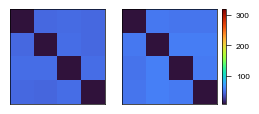

In [49]:
import copy
import os
import matplotlib
from os.path import join as pjoin

def adjust_fig_per_cond(output_figs):
    fig_per_cond_copy = output_figs['fig_per_cond']
    ax = fig_per_cond_copy.get_axes()
    # Remove title for ax[0] and ax[1]
    ax[0].set_title('')
    ax[1].set_title('')
    # Delete y ticks on the second axes
    ax[0].set_yticks([])
    ax[1].set_yticks([])
    # Delete colorbar on the first axes
    fig = fig_per_cond_copy
    # Keep arg-phe
    fig.delaxes(fig.axes[2])
    # fig.delaxes(fig.axes[5])
    # fig.delaxes(fig.axes[2])
    # fig.delaxes(fig.axes[4])
    # fig.delaxes(fig.axes[2])
    fig_per_cond_copy.tight_layout()
    return fig_per_cond_copy

fig_per_cond_copy = adjust_fig_per_cond(output_figs)
save_figure_for_paper(fig_per_cond_copy, f'{dataset_name}_{params.metric}_distance_per_cond_{window_tag}', paper_fig_dir, save_eps=True)
fig_per_cond_copy



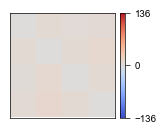

In [50]:
def adjust_fig_delta(output_figs):
    fig_delta_copy = copy.deepcopy(output_figs['fig_delta'])
    ax = fig_delta_copy.get_axes()
    ax[0].set_yticks([])
    fig_delta_copy.tight_layout()
    return fig_delta_copy

fig_delta_copy = adjust_fig_delta(output_figs)
save_figure_for_paper(fig_delta_copy, f'{dataset_name}_{params.metric}_mean_delta_{window_tag}', paper_fig_dir, save_eps=True)
fig_delta_copy

C:\Users\hubob\AppData\Local\Temp\ipykernel_23172\1247299096.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([xtick_mapping[xtick.get_text()] for xtick in xticklabels], fontsize=tick_fontsize)
C:\Users\hubob\AppData\Local\Temp\ipykernel_23172\1247299096.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=tick_fontsize)


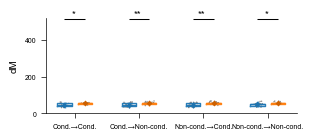

In [51]:
def adjust_fig_multi_vs(output_figs):
    label_fontsize = 7
    tick_fontsize = 5
    fig = output_figs['fig_multi_vs']
    ax = fig.get_axes()[0]
    # Remove legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    # Rest figure size
    fig.set_size_inches(3.3, 1.5)
    # Change ylabel
    ylabel = ax.get_ylabel()
    if ylabel == 'D_M':
        ax.set_ylabel('dM', fontsize=label_fontsize)
    elif ylabel == 'center D_E':
        ax.set_ylabel('dE', fontsize=label_fontsize)

    xticklabels = ax.get_xticklabels()
    if ylabel == 'D_M':
        xtick_mapping = {'learned_vs_learned': 'Cond.→Cond.', 'learned_vs_novel': 'Cond.→Non-cond.',
                            'novel_vs_learned': 'Non-cond.→Cond.', 'novel_vs_novel': 'Non-cond.→Non-cond.'}
    elif ylabel == 'center D_E':
        xtick_mapping = {'learned_vs_learned': 'Cond.↔Cond.', 'learned_vs_novel': 'Cond.↔Non-cond.',
                            'novel_vs_learned': 'Non-cond.↔Cond.', 'novel_vs_novel': 'Non-cond.↔Non-cond.'}
    else:
        xtick_mapping = None
    if xtick_mapping is not None:
        ax.set_xticklabels([xtick_mapping[xtick.get_text()] for xtick in xticklabels], fontsize=tick_fontsize)
    
    # Rotate x tick labels 45 degrees
    # ax.set_xticklabels(ax.get_xticklabels(), rotation=20)

    # Set y tick label size
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=tick_fontsize)
    fig.tight_layout()
    return fig
fig = adjust_fig_multi_vs(output_figs)
save_figure_for_paper(fig, f'{dataset_name}_{params.metric}_multi_vs_{window_tag}', paper_fig_dir)
fig

In [52]:
from catrace.stats import format_test_results_multi_odor_two_cond
sentence = format_test_results_multi_odor_two_cond(test_results)
sentence = sentence.replace('_vs_', ' vs ')
print(sentence)

For learned vs learned, Comparing naive (mean = 46.08 ± 9.51, n = 16) vs trained (mean = 53.29 ± 3.77, n = 18): Mann–Whitney U test, U = 75.00, P = 0.018. For learned vs novel, Comparing naive (mean = 47.09 ± 9.29, n = 32) vs trained (mean = 54.07 ± 5.36, n = 36): Mann–Whitney U test, U = 337.00, P = 0.003. For novel vs learned, Comparing naive (mean = 46.86 ± 9.04, n = 32) vs trained (mean = 54.20 ± 5.98, n = 36): Mann–Whitney U test, U = 334.00, P = 0.003. For novel vs novel, Comparing naive (mean = 48.26 ± 9.35, n = 16) vs trained (mean = 54.87 ± 6.02, n = 18): Mann–Whitney U test, U = 77.00, P = 0.022.


Plotting average trace...
Extracted_Data_mock1_Fish1 None
Computing distance matrices...
F:\FMI_tachyon_hubo\Dp_manifold\BNP_dataset\data\Claire\spike_prob\dorsal\per_odor_aligned\index_formatted_firing_rate\center_euclidean_seed203_window47to70_shuffled_seed121
Plotting per condition...
{'ncol': 2, 'row_height': 1.36, 'col_width': 1.36, 'title_fontsize': 7, 'colorbar_fontsize': 6, 'ylabel_fontsize': 7, 'ylabels': None, 'ylabel_colors': None, 'cmap': 'turbo', 'clim': [0.0, 3.7259818310034922], 'color_norm': None, 'cbar_interval': None, 'manifold_level': 'odor'}
clim: (0.0, 3.7259818310034922)
ylabel_ vfontsize: 7
ylabel_ vfontsize: 7
Plotting delta matrix...
clim: (-1.2550915770948317, 1.2550915770948317)
ylabel_ vfontsize: 7
Plotting vs statistics...
Plotting per fish...


C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(


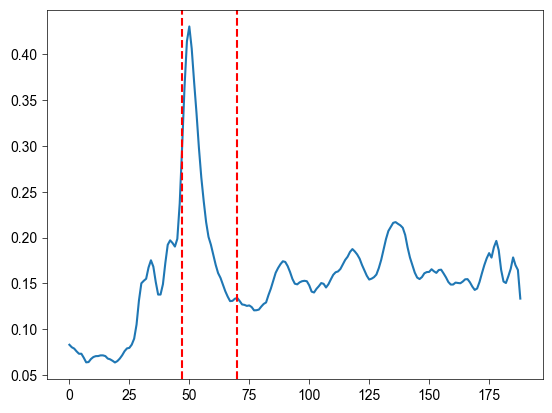

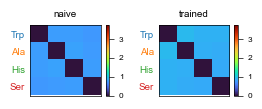

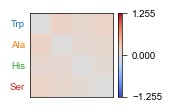

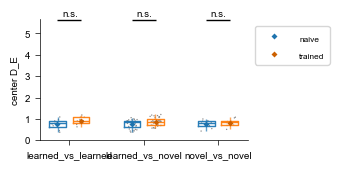

In [53]:
plot_params = PlotDistanceParams(
    per_cond = PlotPerCondMatParams(
        row_height=1.36,
        col_width=1.36,
        title_fontsize=7,
        ylabel_fontsize=7,
        ylabel_colors = None,
        ylabels = None,
        clim=(0.0, 3.7259818310034922),
    ),
    mean_delta = PlotMeanDeltaMatParams(
        figsize=(1.82, 1.82),
        colorbar_fontsize = 7,
        ylabel_fontsize = 7,
        ylabels = ylabels,
        ylabel_colors = ylabel_colors,
        clim=(-1.2550915770948317, 1.2550915770948317),
    ),
    vs_measure = PlotBoxplotMultiOdorCondParams(
        figsize=(3.5, 1.8),
        label_fontsize=7,
        show_ns=True,
        box_linewidth=1,
        strip_size=1,
        mean_marker_size=1,
        pvalue_marker_xoffset=0.05,
        ylim=(0, 5.6835741178251755)
    ))
import copy
vsdict_euclidean = copy.deepcopy(vsdict)
# Revmove novel_vs_learned
del vsdict_euclidean['novel_vs_learned']

params = RunDistanceParams(
    config_file = '../dataset_configs/adult_dataset_t7.json',
    assembly_name = '',
    time_window = [47, 70],#[40, 78],
    sample_size = 70,
    metric = 'center_euclidean',
    seed=seed,
    do_normalize_simdf = False,
    do_reorder_cs = False,
    vsnames = ['learned_vs_learned', 'learned_vs_novel', 'novel_vs_novel'],
    overwrite_computation = False,
    vs_same_ylim=None,#[90, 370],
    reg=1e-5,
    do_plot_per_fish = False,
    vsdict=vsdict_euclidean,
    plot_params = plot_params,
    parallelism = 20,
    do_shuffle_manifold_pair_labels = True,
    shuffle_master_seed = shuffle_master_seed,
    num_repeats = 50,
    manifold_level = 'odor')

if params.assembly_name == '':
    assembly_label = 'all_neurons'
else:
    assembly_label = params.assembly_name
params.summary_name = f'distance_summary_{params.metric}_{assembly_label}_window{params.time_window[0]}to{params.time_window[1]}_norm{params.do_normalize_simdf}'

output_figs, test_results, avg_simdf = run_distance(params, return_data=True)

# Save result data to CSV
import os
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure06')
os.makedirs(save_dir, exist_ok=True)
avg_simdf.to_csv(os.path.join(save_dir, f'extended_figure06d_adult_shuffled_euclidean_distances_matrices.csv'))

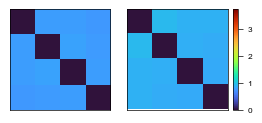

In [54]:
fig_per_cond_copy = adjust_fig_per_cond(output_figs)
save_figure_for_paper(fig_per_cond_copy, f'{dataset_name}_{params.metric}_distance_per_cond_{window_tag}', paper_fig_dir, save_eps=True)
fig_per_cond_copy


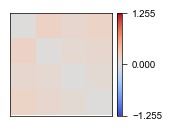

In [55]:
fig_delta_copy = adjust_fig_delta(output_figs)
save_figure_for_paper(fig_delta_copy, f'{dataset_name}_{params.metric}_mean_delta_{window_tag}', paper_fig_dir, save_eps=True)
fig_delta_copy

In [56]:
from catrace.stats import format_test_results_multi_odor_two_cond
sentence = format_test_results_multi_odor_two_cond(test_results)
sentence = sentence.replace('_vs_', ' vs ')
print(sentence)

For learned vs learned, Comparing naive (mean = 0.76 ± 0.248, n = 8) vs trained (mean = 0.92 ± 0.180, n = 9): Mann–Whitney U test, U = 23.00, P = 0.236. For learned vs novel, Comparing naive (mean = 0.76 ± 0.202, n = 32) vs trained (mean = 0.87 ± 0.188, n = 36): Mann–Whitney U test, U = 430.00, P = 0.074. For novel vs novel, Comparing naive (mean = 0.77 ± 0.196, n = 8) vs trained (mean = 0.83 ± 0.177, n = 9): Mann–Whitney U test, U = 31.00, P = 0.673.


C:\Users\hubob\AppData\Local\Temp\ipykernel_23172\1247299096.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([xtick_mapping[xtick.get_text()] for xtick in xticklabels], fontsize=tick_fontsize)
C:\Users\hubob\AppData\Local\Temp\ipykernel_23172\1247299096.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=tick_fontsize)


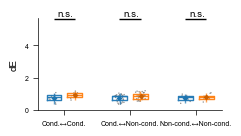

In [57]:
fig = adjust_fig_multi_vs(output_figs)
# Set figure size
fig.set_size_inches(2.3, 1.45)
save_figure_for_paper(fig, f'{dataset_name}_{params.metric}_multi_vs_{window_tag}', paper_fig_dir)
fig